## Project Overview

Between 2018 and 2026, the Global economy was hit by a sequence of distinct structural shocks including the COVID 19 pandemic, aggressive tariffs, and war abroad. I have chosen February 5th, 2018 to May 15th, 2026, because this marks when Jerome Powell served as chair on the Federal Reserve. <br><br> In this project, I will analyze the 10 Year Breakeven Inflation Rate (T10YIE) from **February 5th 2018** to **May 15th 2026** and in doing so:
+ Smooth noise and identify trends using **Moving Averages**
+ Measure the momentum and acceleration of **Year over Year changes**
+ Visualize volatility and extremes with **Bollinger Bands**
+ Forecast short term inflation sentiment using **Exponential Smoothing**
+ Research co-movements in oil prices with **Rolling Correlation**

The T10YIE represents the market based estimate of average inflation over the next decade and is an advantageous metric to evaluate for several reasons, as it:
+ Informs us on whether we can expect the Federal Reserve to cut or raise interest rates in the near term
+ Measures whether markets price inflation as a persistent threat or a series of transitory shocks
+ Tracks real time investor reactions to geopolitical and trade tensions

Ultimately, this analysis will provide more insight into how inflation expectations have evolved through post-pandemic recovery and geopolitical conflicts.

## Data Exploration 

In this section, I will perform an initial exploration of the 10-Year Breakeven Inflation Rate dataset that the Federal Reserve Bank of St. Louis makes available at <https://fred.stlouisfed.org/series/T10YIE>

![Alt text](Images/fredgraph.png)

### Load Libraries and Dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import holidays
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_excel('Data/T10YIE.xlsx', sheet_name=1)
df.head()

,observation_date,T10YIE
0,2018-02-05,2.10
1,2018-02-06,2.10
2,2018-02-07,2.10
3,2018-02-08,2.09
4,2018-02-09,2.05


### Describe Dataset

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2160 entries, 0 to 2159
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   observation_date  2160 non-null   datetime64[ns]
 1   T10YIE            2070 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 33.9 KB


In [5]:
df['T10YIE'].describe()

count    2070.000000
mean        2.144763
std         0.360505
min         0.500000
25%         1.962500
50%         2.260000
75%         2.360000
max         3.020000
Name: T10YIE, dtype: float64

### Check for Missing Values and Date Range

In [6]:
df.isna().sum()

observation_date     0
T10YIE              90
dtype: int64

In [7]:
us_holidays = holidays.UnitedStates(state='NJ') # New Jersey Recognizes All Federal Holidays, Including Good Friday
df['is_holiday'] = df['observation_date'].dt.date.apply(lambda x: x in us_holidays)
df[df['T10YIE'].isna()].groupby(['is_holiday'])['T10YIE'].size().reset_index(name='n_days')

,is_holiday,n_days
0,False,1
1,True,89


In [8]:
# December 5, 2018, was a National Day of Mourning for former President George H.W. Bush, resulting in a missing T10YIE observation
df.loc[(df['is_holiday']==False) &(df['T10YIE'].isna()), ]

,observation_date,T10YIE,is_holiday
217,2018-12-05,NaN,False


There's Missing Inflation Data on Federal Holidays, Which We Treat Using **Forward Filling**
<br>&emsp; **Forward Filling:** Taking the Last Known Valid Observation Forward to Fill in Subsequent Missing Data

In [9]:
df['T10YIE'] = df['T10YIE'].ffill()
df = df.drop('is_holiday', axis=1).sort_values('observation_date')

### Time Visualization

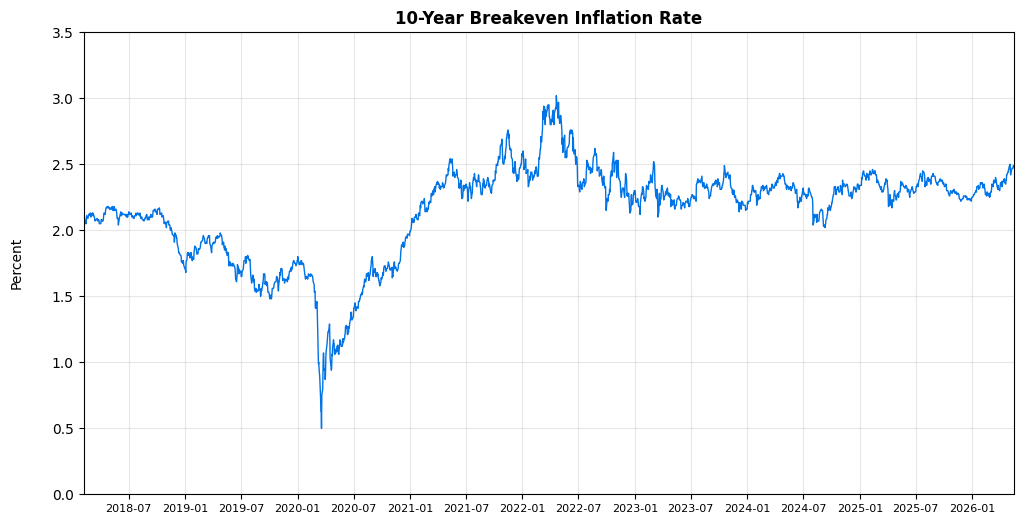

In [10]:
# 10-Year Breakeven Inflation Rate
plt.figure(figsize=(12,6))
plt.margins(x=0.0001)
plt.grid(alpha=0.3)
plt.title('10-Year Breakeven Inflation Rate', fontsize=12, fontweight='bold')
plt.plot(df['observation_date'], df['T10YIE'], color='#0073e6', linewidth=1)
plt.ylabel('Percent', labelpad=20)
plt.ylim(0, 3.5)
plt.xticks(fontsize=8)
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7]))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.show()

## Background
This plot shows the 10-Year Breakeven Inflation Rate across distinct phases and is covered below in detail:

+ **2018-2019** <br> In the wake of the 2008 Financial Crisis, a distressed period from 2009 to 2016 beset with government bailouts, near-zero interest rates, and Quantitative Easing (QE), the Federal Reserve maintained highly accommodative monetary policies, explaining to some degree the elevated levels of inflation found at the start of the chart above.
<br><br>
To combat inflation, the Federal Reserve shifted towards stricter, hawkish policies such as reducing its purchases of government debt and raising interest rates to a range of 2.25% - 2.50%, which contributed to a noticeable decline in the T10YIE through 2018 and into much of 2019; however, this shift removed much of the liquidity that had previously boosted a strained economy.
<br><br>
When the Federal Reserve reduced its holdings of Treasury bills (T-bills) and mortgage backed securities, it took cash out of circulation by allowing more cash to remain on its balance sheet rather than being invested back into government debt and home loans. Because cash was taken out at unprecedented levels, this sparked concerns of a liquidity crisis as the financial system had grown increasingly dependent on this large outflow of cash into the economy that had allowed borrowing rates to remain suppressed. 
<br><br>
By May 2019, the Federal Reserve slowed its pace in reducing the size of its balance sheet. Starting in October 2019, they began purchasing `$60B` in T-bills to address the liquidity crisis. These reactive cash injections focused on the short term flow of cash rather than long-term. This more favorable, dovish policy contributes to the moderate increase in the T10YIE observed in the tailend of 2019.
<br>--
    
+ **2020-2021** <br>The COVID-19 pandemic caused a global shutdown, forcing inflation to drop suddenly in early 2020. March 2020 marks the lowest point, at `0.5`, that the T10YIE reached between 2018 and 2026, a drop not seen since the 2008 Financial Crisis. The Federal Reserve responded quickly to prevent a complete collapse of the financial system through several actions that consequently raised inflation aggressively.
<br><br>
Using two unscheduled emergency meetings, the Federal Reserve cut interest rates by 50 basis points (bps) on March 3rd, 2020 and again by 100bps on March 15th, 2020. These cuts brought interest rates to 0% - 0.25%. Alongside interest rate cuts, the Federal Reserve provided dovish forward guidance establishing that near-zero interest rates would be retained until the Federal Reserve was confident that the economy had weathered the shock of the pandemic.
<br><br>
Serving as a backstop to a faltering economy, the Central Bank deployed emergency tools under Section 13(3) of the Federal Reserve Act. To provide relief to a distressed country, the Federal Reserve provided extensive support including the creation of these institutions: 
<br><br>
&nbsp;&nbsp;**Secondary Market Corporate Credit Facility (SMCCF):**
<br>&nbsp;&nbsp;SMCCF provided `14.1B` in liquidity for outstanding corporate bonds between 5/15/2020 and 12/17/2021.
<br><br>
&nbsp;&nbsp;**Paycheck Protection Program Liquidity Facility (PPPLF):**
<br>&nbsp;&nbsp;PPPLF extended `$800B` in credit to eligibile financial institutions between 4/13/2020 and 7/30/2021, ensuring lenders could fund loans for small businesses. 
<br><br>
&nbsp;&nbsp;**Municipal Liquidity Facility (MLF):**
<br>&nbsp;&nbsp;MLF provided `$17.5B` in support between 5/26/2020 and 12/31/2020 to state and local governments that had been facing immediate cash flow pressures.
<br><br>
&nbsp;&nbsp;**Main Street Lending Program (MSLP):**
<br>&nbsp;&nbsp;MSLP supplied `$17.5B` between 7/6/2020 and 1/8/2021 to small and medium sized businesses that were in good standing before the pandemic.
<br><br>
Additionally, the Federal Reserve resumed QE at an accelerated rate from March 2020 to October 2021 before decelerating in November 2021 and tapering QE off entirely by March 2022. The bulk of this balance sheet expansion occurred between March 2020 and May 2020: three months that totaled `$3T`. When the Federal Reserve concluded its QE efforts, the balance sheet had expanded by `$5.3T` in aggregate. 
<br>--

+ **2022-2024** <br>Aggressive economic expansion following the COVID-19 pandemic led to the total assets held by the Federal Reserve exceeding `$8.965T`, the highest ever recorded balance in the entire Federal Reserve's history. When the Federal Reserve expanded its balance sheet, the move served as a signal to Congress that they can engage in elevated levels of discretionary spending. Consequently, the federal budget deficit, measuring the difference between what the U.S. government collects in revenue (receipts) and spends (outlays), increased by 33.21% from 2022 to 2024. This increase in government spending contributed to a rise in inflation as the T10YIE reached its peak of `3.02` on April 21st, 2022, and for the most part, hasn't fallen back to pre-pandemic levels.
<br><br>
The heightened level of inflation seen in the first half of 2022 was further exacerbated by the Russian invasion of Ukraine on February 24th, 2022, as oil prices rose on news of the outbreak. War meant not only human suffering but also economic pain. Russia accounted for roughly 11% of the world's oil production, and conflict caused Brent crude to surge from around `$101` to as high as `$133` a barrel. Through releasing `180M` barrels of oil from the Strategic Petroleum Reserve (SPR), the United States helped drive the cost of oil down to stable levels by the end of 2022. With oil falling in price, inflation declined from a four decade high by the end of 2022.
<br><br>
To help rein in inflation, the Federal Reserve quickly raised interest rates and resumed Quantitative Tightening (QT) by allowing more cash to remain on its balance sheet rather than being reinvested into the economy. Interest rate hikes were announced from March 17th, 2022 through July 27th, 2023 by Jerome Powell after the Federal Open Markets Committee (FOMC) voted overwhelmingly in favor of raising rates. The near-zero interest rates that had fueled the United States economy were replaced with rates as high as 5.25% - 5.50%, lending conditions tightened, and the cost of doing business for many significantly increased. These fiscal positions helped moderate inflation across 2023 - 2024, and through policies like the CHIPS and Sciences act, the United States supply chain regained some stability lost during the COVID-19 pandemic. However, firms also began to look for ways to cut costs and often did so through layoffs.
<br><br>
Significant increases in layoffs coincided with the emergence and continued development of artificial intelligence (AI). AI, quantum computing, and robotics, among other areas of research, gained `$200B` in public funding through the enactment of the CHIPS and Science Act on August 9th, 2022. Before Google's Gemini and Anthropic's Claude models, OpenAI launched ChatGPT as a non-profit organization on November 30th, 2022 with the mission to ensure that artificial general intelligence benefits all of humanity. Questionable progress has been made towards that goal, as the organization transitioned into a 'capped-profit' structure and focused heavily on commercial licensing deals, leading to internal conflicts over whether the drive for revenue has compromised its original commitment to the greater good of humanity. From 2022 to 2024, global corporate investment into AI exceeded `$700B`, showing no signs of slowing down in 2025 and 2026. Meanwhile, layoffs from 2022 to 2024 surpassed `1.84M`. The Federal Reserve responded to this downturn in employment by cutting interest rates by 25bps September 18th, 2024 through December 18th, 2024, lowering rates to 4.25% - 4.50%. This decrease in interest rates can help explain the increase in the T10YIE observed in the second half of 2024. 
<br>--
+ **2025-2026**<br>
Continuing into 2025, the T10YIE hovered around `2.4` in the first quarter before dropping down to `2.29` by mid March. A noticeable driver in the decline of the T10YIE was the decrease in energy costs. From January 17th, 2025 - March 2nd, 2026, Brent crude oil prices have remained, for the most part, below `$80` and as low as `$60` a barrel. This is due to the United States producing record levels of energy in 2025, with offshore oil production totaling over `714M` barrels, the highest annual output on record. Even though there were numerous initiatives aimed at lowering Year-over-Year (YoY) changes in the price of oil alongside prescription drugs, automobiles, and various other goods, the net price consumers are paying has increased. Further, the T10YIE has remained elevated and the Federal Reserve has found excess inflation can be explained by the pass through of tariffs. Though tariffs had a somewhat muted effect on the T10YIE due, in large part, to the frequent changes in the way they've been implemented.
<br><br>
On April 2nd, 2025, new tariffs were announced under the International Emergency Economic Powers Act (IEEPA), with rates ranging from 10% to as high as 50%. These IEEPA rates sparked widespread confusion and outrage, as they were much higher than anticipated. While the rationale provided for their severity was that these were reciprocal tariffs, the formula used to arrive at these punitive levels had reflected the bilateral trade deficit that the United States held with each trading partner. A week later these IEEPA tariffs were largely put on hold, save for the significantly elevated tariffs on China that were raised to 145% and retained until May, 14th, 2025 when both sides finally agreed to a temporary pause. These sweeping tariffs with China and many other major trading partners had resumed again on August 7th, 2025 at negotiated rates. These IEEPA tariffs were in place until February 20th, 2026 when the Supreme Court ruled them unconstitutional in Learning Resources, Inc. v. Trump and the U.S. Court of International Trade ordered that the `$166B` garnered through IEEPA tariffs be refunded. Following the Supreme Court's ruling, the administration invoked Section 122 of the Trade Act of 1974 to implement a 10% global surcharge. These specific tariffs have an expiration date of July 24th, 2026. If a trade deficit with partner nations persists, then the administration may levy more permanent duties on imported goods; however, the trade deficit continues to shrink.
<br><br>
Data from the Bureau of Economic Analysis (BEA) and the Joint Economic Committee (JEC) indicates that the Annual Goods and Services deficit shrank from `$903.5B` in 2024 to `$901.5B` in 2025. This downward trend accelerated into 2026. During the first two months of the year, the deficit fell by `$136.1B`, representing a `54.8%` drop compared to the same period in 2025. This shift stems from a `$62.6B` (`11.3%`) surge in exports, with key contributors including industrial supplies, non-monetary gold, and natural gas. The latter had experienced significant momentum as global markets prioritized secure and stable energy sources in the midst of the Iran War. A global energy crisis due to the closure of the Strait of Hormuz had driven the price of oil to the highest point it has been at since the Russian invasion of the Ukraine. This waterway is a critical chokepoint, as approximately one fifth of global oil consumption passes through it daily. The tension present in the Middle East has driven an increased global reliance on the United States for energy. This tension is reflected in the T10YIE, as the metric continues to increase towards the end of the chart.
<br><br>
As the Federal Reserve balances its dual mandate of price stability and maximum employment, persistent inflation has complicated the trajectory for interest rates and balance sheet management. Following 25bps cuts in September, October, and December of 2025, the federal funds rate reached a range of 3.50% - 3.75%. While the reductions were intended to support growth, the inflationary pressures caused by the energy crisis had prompted a continued pause in further adjustments.
<br><br>
Unfortunately, the uncertainty from the Iran War is widely expected to lead to an increase in layoffs that will eventually prompt the Federal Reserve to continue to lower interest rates when the price of oil drops. This continued reduction is made more obvious, because Kevin Warsh, a known proponent of rate cuts, has been confirmed as the new chair of the Federal Reserve. It is believed that Kevin Warsh will shrink the Federal Reserve's balance sheet in an effort to allow for significant reductions in interest rates. In my own opinion, I believe the T10YIE will drop significantly in the second half of 2026, as oil drops in price, layoffs rise, and tariffs expire. 
<br>--

## Trend Analysis
This section applies trend analysis techniques to extract nuanced insights from the time series data.

### Moving Averages
Moving averages smooth short-term fluctuations and help reveal underlying trends. They are a simple yet effective tool in time series analysis.
<br>
A **30-day moving average** highlights recent shifts, while a **90-day moving average** captures broader, more structural trends.
<br>
**Crossovers** between short and long-term averages often act as early indicators of **uptrends or downtrends**.

#### Interpretation Guide
Moving averages effectively filter out daily noise to reveal the core direction inflation is headed. Different windows provide distinct insights into market expectations:
<br><br>
**Short-Term Moving Average (30 Days):** <br> 
These averages are designed to identify immediate fluctuations and responsive inflationary pressures.
<br><br>
**Long-Term Moving Average (90 Days):** <br> 
These averages focus on structural shifts and sticky inflation.
<br><br>
**Crossover Event:** <br> 
When the short-term moving averages rise above the long-term moving average, it indicates an upward trajectory for inflation.

#### Implementation and Visualization 

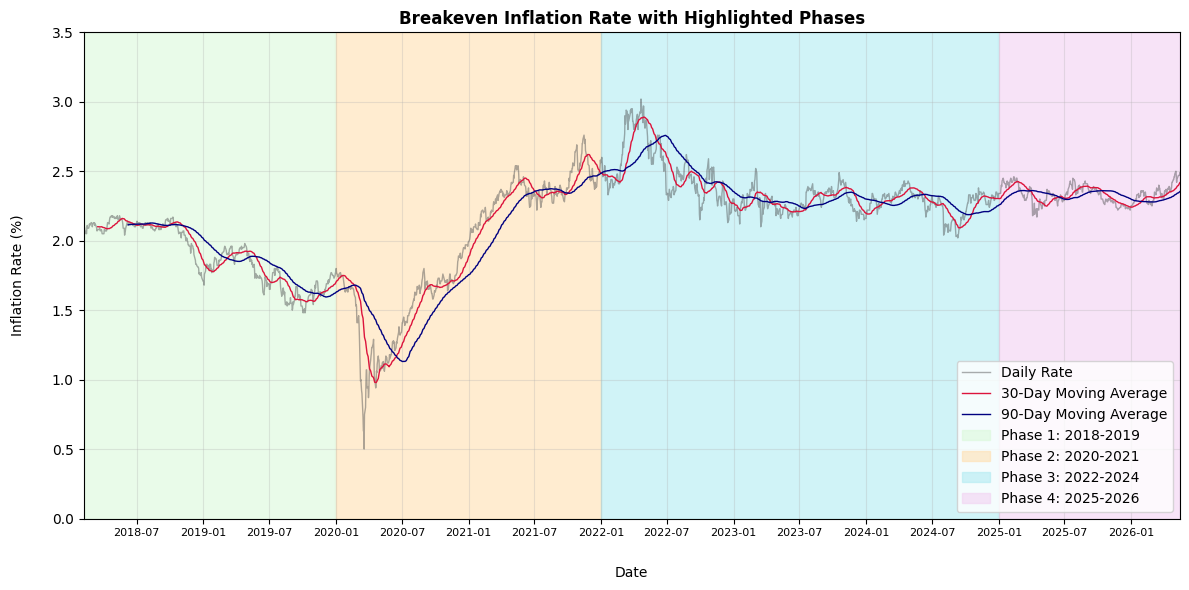

In [11]:
# Moving Averages
df['MA_30'] = df['T10YIE'].rolling(window=30).mean()
df['MA_90'] = df['T10YIE'].rolling(window=90).mean()

# Breakeven Inflation Rate with Highlighted Phases
plt.figure(figsize=(12,6))
plt.margins(x=0.0001)
plt.grid(alpha=0.3)
plt.title('Breakeven Inflation Rate with Highlighted Phases', fontsize=12, fontweight='bold')
plt.plot(df['observation_date'], df['T10YIE'], label='Daily Rate', alpha=0.45, color='#48494B', linewidth=1)
plt.plot(df['observation_date'], df['MA_30'], label=('30-Day Moving Average'), color='#DC143C', linewidth=1)
plt.plot(df['observation_date'], df['MA_90'], label=('90-Day Moving Average'), color='#000080', linewidth=1)
plt.ylabel('Inflation Rate (%)', labelpad=20)
plt.xlabel('Date', labelpad=20)
plt.ylim(0, 3.5)
plt.xticks(fontsize=8)
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7]))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

# Create Phases
plt.axvspan(pd.to_datetime('2018-02-05'), pd.to_datetime('2019-12-31'), 
            color='#DBF9DB', alpha=0.6, label='Phase 1: 2018-2019')

plt.axvspan(pd.to_datetime('2020-01-01'), pd.to_datetime('2021-12-31'), 
            color='#FFE0B2', alpha=0.6, label='Phase 2: 2020-2021')

plt.axvspan(pd.to_datetime('2022-01-01'), pd.to_datetime('2024-12-31'), 
            color='#B2EBF2', alpha=0.6, label='Phase 3: 2022-2024')

plt.axvspan(pd.to_datetime('2025-01-01'), pd.to_datetime('2026-05-15'), 
            color='#F2D1F2', alpha=0.6, label='Phase 4: 2025-2026')

# Ancillary 
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

#### Interpretation
The moving averages reveal distinct patterns across four distinct phases of inflation expectations:

+ **Phase 1: 2018-2019** <br>
The 30-Day Moving Average came down quicker than the 90-Day Moving Average, as monetary policies pushed inflation expectations down and short-term fluctuations acted quicker than long-term. The 30-Day Moving Average rose above the 90-Day Moving Average in 2019 twice, indicating two crossover events. This inversion means the market expected high inflation in the short term, but believed inflation would cool down eventually.<br>

| Range | Value (%) |
| --- | --- |
| Daily Inflation Range | 1.48 - 2.18 | 
| 30-Day Moving Average Range | 1.56 - 2.16 |
| 90-Day Moving Average Range | 1.59 - 2.13 |

+ **Phase 2: 2020-2021** <br>
Following a brief increase in inflation expectations, the 30-Day Moving Average dropped sharply during the outbreak of the COVID-19 pandemic. This initial decline acts as a precursor for the 90-Day Moving Average, which follows a similar path, albeit less intense. This lagging response produced a crossover event midway through 2020 where the 30-Day Moving Average rose above the 90-Day Moving Average. The 30-Day Moving Average remained elevated above the 90-Day Moving Average for much of 2020 and 2021. This trend shows how prices in the short-term were expected to rise rapidly and remain relatively unchanged in the near term, as the 90-Day Moving Average followed this rise in momentum.<br>

| Range | Value (%) |
| --- | --- |
| Daily Inflation Range | 0.5 - 2.76 | 
| 30-Day Moving Average Range | 0.98 - 2.62 |
| 90-Day Moving Average Range | 1.13 - 2.46 |

+ **Phase 3: 2022-2024** <br>
Stemming from dovish monetary policy, the 30-Day Moving Average hit a four decade high inflection point, experiencing a short lived crossover event that presaged the 90-Day Moving Average peak. From 2022 through 2024, there are six separate crossover events. This frequent recurrence is representative of the sticky inflation that plagued this period.<br>

| Range | Value (%) |
| --- | --- |
| Daily Inflation Range | 2.02 - 3.02 | 
| 30-Day Moving Average Range | 2.09 - 2.89 |
| 90-Day Moving Average Range | 2.19 - 2.76 |

+ **Phase 4: 2025-2026** <br>
In 2025 and 2026, the 30-Day Moving Average continued to crossover the 90-Day Moving Average frequently. This time period continued to be inflicted by the same sticky inflation that the previous phase had endured. Similarly, the expected inflation rate remained elevated.<br>

| Range | Value (%) |
| --- | --- |
| Daily Inflation Range | 2.17 - 2.48 | 
| 30-Day Moving Average Range | 2.24 - 2.43 |
| 90-Day Moving Average Range | 2.26 - 2.36 |

### Year-over-Year Change
The Year-over-Year (YoY) technique measures the momentum of inflation sentiment by assessing how today's inflation expectations compare to the same day one year ago. This technique helps filter out daily noise and seasonality to reveal general market expectations on whether inflation is accelerating or cooling. Fundamentally, YoY changes indicate both directional speed and level of expected inflation 10 years in the future.

#### Interpretation Guide
+ **Positive Change:**
<br>
Positive values indicate expectations that inflation will rise
<br><br>
+ **Negative Change:**
<br>
Negative values point to anticipated declines in inflation
<br><br>
+ **Near Zero Change:**
<br>
Values near zero represent negligible change

#### How Are Year-over-Year Changes Measured?
The following formula is used to compute Year-over-Year change in the T10YIE: 
<br>

**Formula:** <br>
$$\text{YoY Change} = \text{Current Value} - \text{Value 365 Days Ago}$$

#### Implementation and Visualization

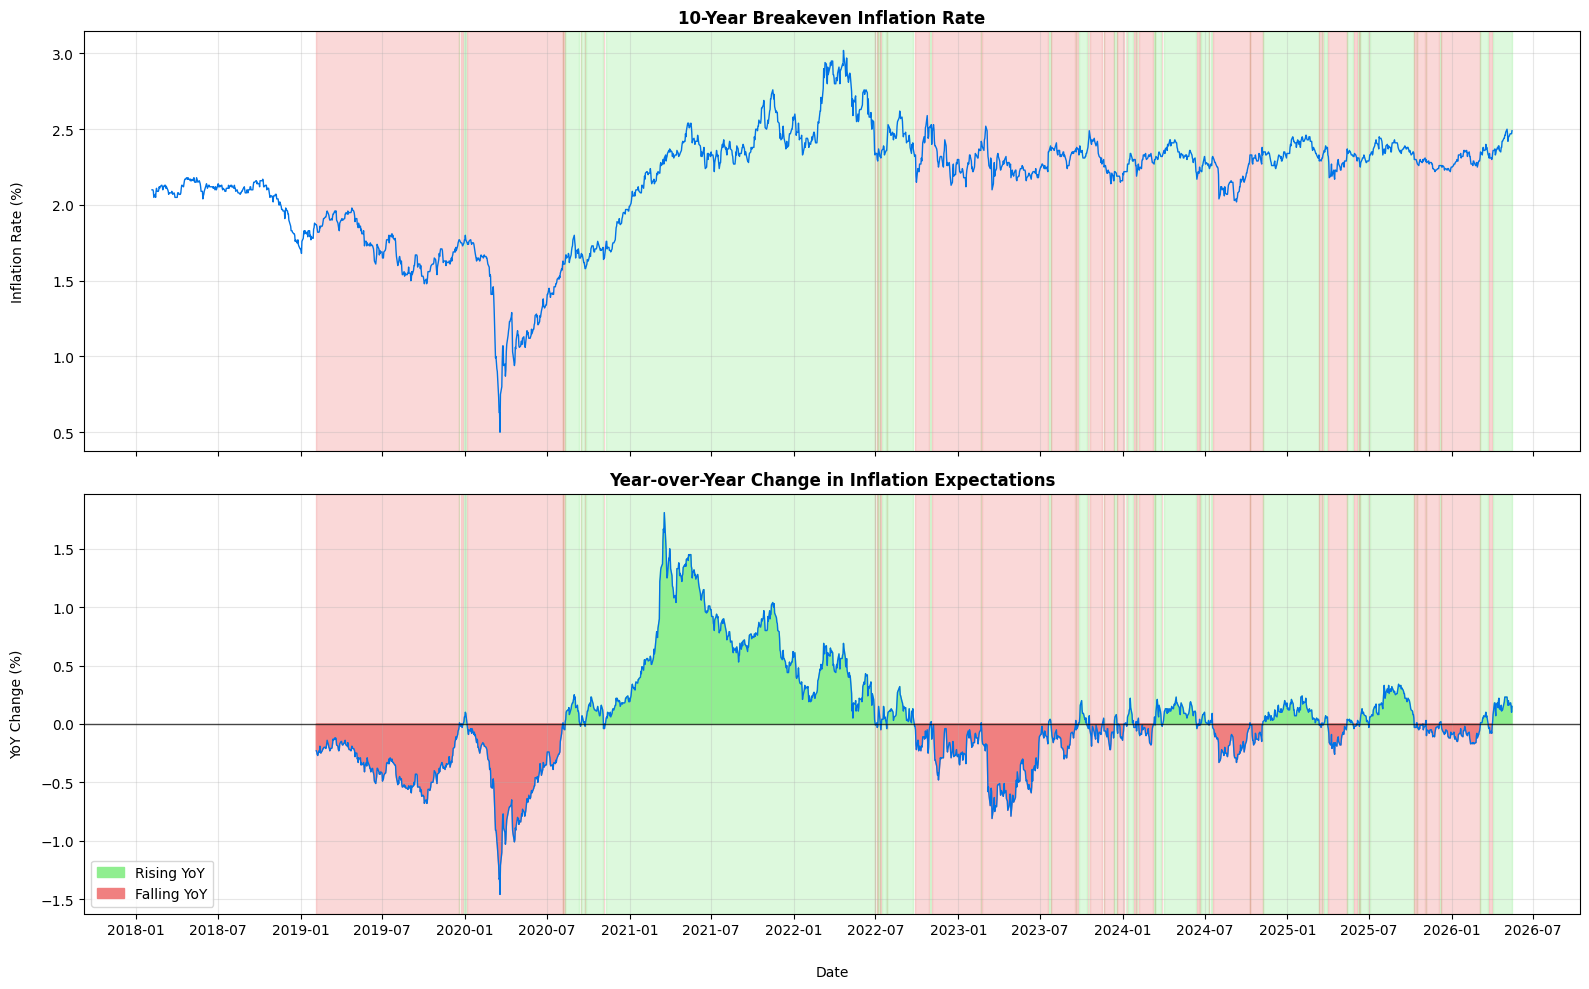

In [12]:
# Inflation Rate and Year-over-Year Change
df['T10YIE'] = df['T10YIE'].ffill()
df_daily = df.set_index('observation_date')[['T10YIE']].resample('D').ffill()
df_daily['YoY_Change_True'] = df_daily['T10YIE'].diff(365)
df['YoY_Change'] = df['observation_date'].map(df_daily['YoY_Change_True'])

# Define Direction
df['Direction'] = np.nan
df.loc[df['YoY_Change'] < 0, 'Direction'] = 'Falling'
df.loc[df['YoY_Change'] > 0, 'Direction'] = 'Rising'
df['Direction'] = df['Direction'].ffill().bfill()

# Exclude Because No Year-over-Year Change
df_valid = df.dropna(subset=["YoY_Change"]).copy()

# Create Unique IDs for Each Continuous Block
df_valid['regime_id'] = (df_valid['Direction'] != df_valid['Direction'].shift()).cumsum()

# Aggregate to Find Start, End, and Direction of Each Zone
zones = (
    df_valid.groupby('regime_id')
    .agg(
        start=('observation_date', 'min'),
        end=('observation_date', 'max'),
        direction=('Direction', 'first'),
    )
    .reset_index()
)

# Create Figure with Shared Axis
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

# 10-Year Breakeven Rate
ax1.grid(alpha=0.3)
ax1.set_title('10-Year Breakeven Inflation Rate', fontsize=12, fontweight='bold')
ax1.plot(df['observation_date'], df['T10YIE'], color='#0073e6', linewidth=1)
ax1.set_ylabel('Inflation Rate (%)', labelpad=20)

# YoY Change in Inflation Expectations
ax2.grid(alpha=0.3)
ax2.set_title('Year-over-Year Change in Inflation Expectations', fontsize=12, fontweight='bold')
ax2.plot(df['observation_date'], df['YoY_Change'], color='#0073e6', linewidth=1)
ax2.set_ylabel('YoY Change (%)', labelpad=12)
ax2.set_xlabel('Date', labelpad=20)
ax2.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7]))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax2.axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.7)
ax2.fill_between(df['observation_date'], df['YoY_Change'], 0, where=(df['YoY_Change'] > 0), color='#90EE90', label='Rising YoY')
ax2.fill_between(df['observation_date'], df['YoY_Change'], 0, where=(df['YoY_Change'] <= 0), color='#F08080', label='Falling YoY')

# Create Background
color_map = {'Rising': '#90EE90', 'Falling': '#F08080'}
for _, zone in zones.iterrows():
    current_color = color_map.get(zone['direction'])
    if current_color:
        ax1.axvspan(zone['start'], zone['end'], color=current_color, alpha=0.3)
        ax2.axvspan(zone['start'], zone['end'], color=current_color, alpha=0.3)

# Ancillary
ax2.legend(loc='lower left')
plt.tight_layout()
plt.show()

#### Interpretation
This chart compares the 10-Year Breakeven Inflation Rate (top chart) with the Year-over-Year Change in inflation expectations (bottom chart), capturing market derived long-term expectations and underlying momentum.

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;**Phase 1: February 5th, 2019 - August 10th, 2020** (Duration: $553$ days) <br> 
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;We start measuring Year-over-Year Change in inflation expectations on February 5th, 2019 as this is one year after the project’s starting point of February 5th,<br>&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;2018.<br>

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;In this phase, Year-over-Year Change is generally negative, as the market expected inflation to fall in the long-term. The lowest point in inflation expectations was <br>&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;reached on March 19th, 2020 with a negative change of -1.46 and a T10YIE of 0.50.<br>

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;There are points that indicate a rise in inflation expectations occurring around early 2020, as well as in the third quarter of 2020. Specifically, on August 10th, 2020 <br> &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;there is a near zero Year-over-Year Change of -0.05 when T10YIE hit 1.61, marking the last point of this extended contraction.<br>

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;Here are a few important metrics to help characterize this phase:<br>
| Metric | T10YIE (%) | Year-over-Year Change (%) |
| --- | --- | --- |
| Range | 0.50 - 1.98 | -1.46 - 0.10 |
| Mean | 1.57 | -0.40 |
| Median | 1.63 | -0.36 |

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;**Phase 2: August 11th, 2020 - September 23rd, 2022** (Duration: $774$ days) <br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;Following an extended contraction in inflation expectations, Year-over-Year Change rose quickly from August 11th, 2020 until there was a pullback in the third<br>&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;quarter of 2022.<br>

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;Through this phase, Year-over-Year Change remained mostly positive, as the market believed that inflation would rise in the long-term. Inflation expectations hit<br>&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;a 40 year peak on March 19th, 2021 with a positive change of 1.81 and a T10YIE of 2.31.

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;There are a couple of moments in this phase where inflation expectations fell, such as in late 2020 and in the second half of 2022. While some of those moments<br>&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;when inflation appeared to be contracting were short-lived and sporadic, by the third quarter of 2022 there was more market consensus that long-term inflation <br>&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;expectations would moderate.<br>

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;Here again are some important metrics that provide more context for this phase:<br>

| Metric | T10YIE (%) | Year-over-Year Change (%) |
| --- | --- | --- |
| Range | 1.58 - 3.02 | -0.05 - 1.81 |
| Mean | 2.32 | 0.53 |
| Median | 2.38 | 0.48 |

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;**Phase 3: September 26th, 2022 - March 13th, 2024** (Duration: $535$ days) <br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;Inflation expectations continued to decline from a 40 year peak, with Year-over-Year Changes falling in relative terms by September 26th, 2022;<br> &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;only, this phase of contraction was marred by inflation that seemed to stick around.<br>

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;Year-over-Year Change in this period fell to as low as -0.81 when T10YIE hit 2.1 on March 17th, 2023. This T10YIE remained above the max value of 1.98 that was <br> &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;experienced in Phase 1, highlighting how inflation expectations can fall in Year-over-Year terms but remain elevated in a more general sense.<br>

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;Inflation expectations grew during two key periods. From September 26th, 2023 to October 13th, 2023, the positive change in Year-over-Year inflation<br>&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;expectations ranged from 0 to 0.2, while the T10YIE range was between 2.31 and 2.39 before coming back down.<br>

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;Similarly, during the second growth period from January 12th, 2024 to January 25th, 2025 Year-over-Year expectations spanned 0 - 0.22 and the T10YIE ranged<br>&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;2.27 - 2.34 prior to reversing course. <br>

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;The metrics below provide more background into this broader phase of contracting inflation expectations:<br>

| Metric | T10YIE (%) | Year-over-Year Change (%) |
| --- | --- | --- |
| Range | 2.1 - 2.59 | -0.81 - 0.22 |
| Mean | 2.29 | -0.20 |
| Median | 2.28 | -0.13 |
 
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;**Phase 4: March 14th, 2024 - May 15th, 2026** (Duration: $793$ days) <br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;In starting to evaluate this phase, I want to begin by highlighting how there are a mixture of times when the general market expected long-term inflation to<br>&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;rise only to seemingly reverse course within the next few months. These sudden changes in expectations are representative of uncertainty plaguing trade policy<br>&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;alongside elevated geopolitical tensions. Here’s a high-level overview for each fluctuation:<br>

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;March 14th, 2024 - July 18th, 2024:<br> 
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;Year-over-Year Inflation Expectations Range: -0.04 - 0.23<br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;T10YIE Range: 2.17 - 2.43

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;July 19th, 2024 - November 7th, 2024:<br> 
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;Year-over-Year Inflation Expectations Range: -0.33 - 0.01<br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;T10YIE Range: 2.02 - 2.38

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;November 8th, 2024 - March 31st, 2025:<br> 
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;Year-over-Year Inflation Expectations Range: -0.03 - 0.24<br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;T10YIE Range: 2.24 - 2.46

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;April 1st, 2025 - June 11th, 2025:<br> 
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;Year-over-Year Inflation Expectations Range: -0.26 - 0.04<br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;T10YIE Range: 2.17 - 2.37

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;June 12th, 2025 - October 9th, 2025:<br> 
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;Year-over-Year Inflation Expectations Range: -0.03 - 0.34<br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;T10YIE Range: 2.25 - 2.45

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;October 10th, 2025 - March 5th, 2026:<br> 
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;Year-over-Year Inflation Expectations Range: -0.17 - 0.03<br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;T10YIE Range: 2.22 - 2.36

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;March 6th, 2026 - May 15th, 2026:<br> 
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;Year-over-Year Inflation Expectations Range: -0.08 - 0.23<br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;T10YIE Range: 2.30 - 2.50<br>      

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;The following metrics provide an overview of this phase of rapid change and ultimately point to a recent rise in long-term inflation expectations, as <br>&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;Year-over-Year Change is positive on average.<br>

| Metric | T10YIE (%) | Year-over-Year Change (%) |
| --- | --- | --- |
| Range | 2.02 - 2.50 | -0.33 - 0.34 |
| Mean | 2.31 | 0.02 |
| Median | 2.32 | 0.03 |

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;This Year-over-Year Change in Inflation Expectations analysis has captured a general trend where a period of rising inflation is followed by a cyclical drop in<br>&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;inflation and, although it isn’t guaranteed, I believe that inflation will fall in the second half of 2026.

### Bollinger Bands
Bollinger Bands use standard deviation to establish upper and lower boundaries around a moving average. The bands expand during volatile periods and contract when market uncertainty calms down. In my analysis, Bollinger Bands reveal when inflation expectations are within normal historical ranges (inside bands), as well as when inflation expectations are reaching new, outlier levels (outside bands).<br><br>
When the rate touches the upper band, it signals unusually high expectations, while touching the lower band indicates unusually low expectations. It is important to note that roughly **88% of the data** falls within these boundaries.
<br><br>**Formulas:**<br>
$$\text{Middle Band} = \text{30-Day Moving Average}$$
$$\text{Upper Band} = \text{Middle Band} + \text{(2 x Standard Deviation)}$$
$$\text{Lower Band} = \text{Middle Band} - \text{(2 x Standard Deviation)}$$

#### Interpretation Guide
The goal of using Bollinger Bands is to measure volatility and identify periods when values deviate significantly from the average. In the context of the 10-Year Breakeven Inflation Rate (T10YIE):<br>

+ When volatility rises, the bands widen and show how uncertain the market is regarding long-term inflation
+ When volatility falls, the bands tighten, signaling more market consensus in general inflation expectations
+ Points outside of the bands represent extreme behavior, while values within are considered normal
+ Upper Band breaches indicate periods of strong inflation sentiment or panic
+ Lower Band breaches suggest unusually low inflation or deflation

#### Implementation and Visualization

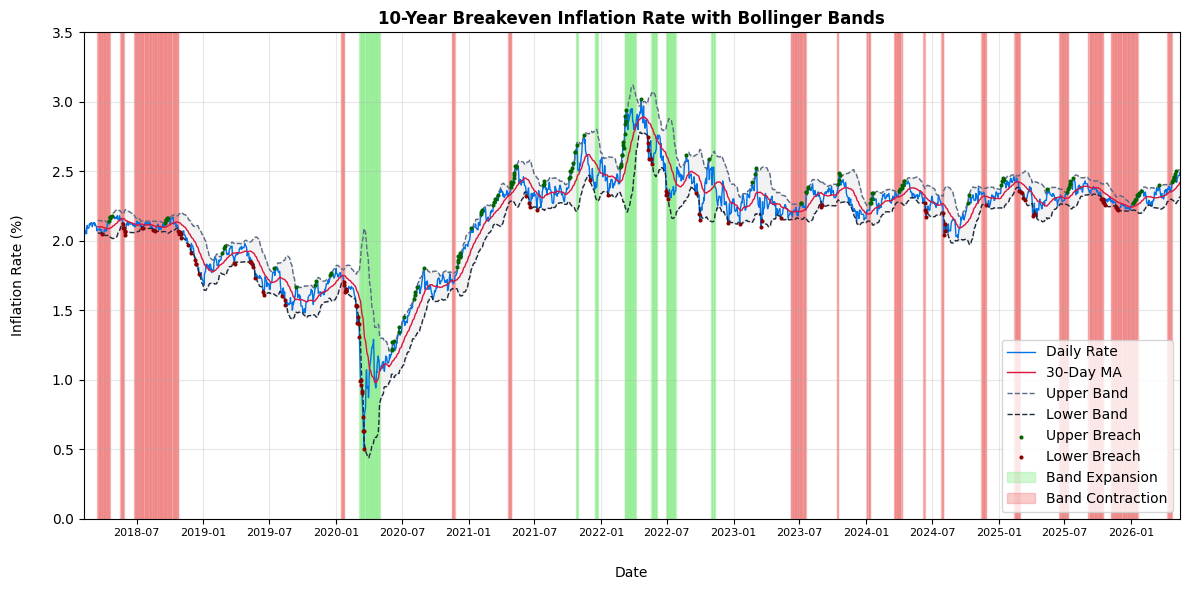

In [13]:
# Bollinger Bands
df['Middle_Band'] = df['T10YIE'].rolling(window=30).mean()
df['Standard_Deviation'] = df['T10YIE'].rolling(window=30).std()
df['Upper_Band'] = df['Middle_Band'] + (2 * df['Standard_Deviation'])
df['Lower_Band'] = df['Middle_Band'] - (2 * df['Standard_Deviation'])
df['Bandwidth'] = df['Upper_Band'] - df['Lower_Band']

# 10-Year Breakeven Inflation Rate with Bollinger Bands
plt.figure(figsize=(12, 6))
plt.margins(x=0.0001)
plt.grid(alpha=0.3)
plt.title('10-Year Breakeven Inflation Rate with Bollinger Bands', fontsize=12, fontweight='bold')
plt.plot(df['observation_date'], df['T10YIE'], label='Daily Rate', color='#0073e6', linewidth=1)
plt.plot(df['observation_date'], df['Middle_Band'], label='30-Day MA', color='#DC143C', linewidth=1)
plt.plot(df['observation_date'], df['Upper_Band'], label='Upper Band', color='#5A6A85', linewidth=1, linestyle='--')
plt.plot(df['observation_date'], df['Lower_Band'], label='Lower Band', color='#1E293B', linewidth=1, linestyle='--')
plt.fill_between(df['observation_date'], df['Upper_Band'], df['Lower_Band'], alpha=0.1, color='#808080')
plt.ylabel('Inflation Rate (%)', labelpad=20)
plt.xlabel('Date', labelpad=20)
plt.ylim(0, 3.5)
plt.xticks(fontsize=8)
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7]))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

# Identify Points Daily Rate Breaches Upper and Lower Band
df['Upper_Breach'] = df['T10YIE'] > df['Upper_Band']
df['Lower_Breach'] = df['T10YIE'] < df['Lower_Band']

# Plotting Breach Points as Scatter Plots
plt.scatter(df[df['Upper_Breach']]['observation_date'], df[df['Upper_Breach']]['T10YIE'], 
            color='#006400', marker='.', s=15, label='Upper Breach', zorder=5)

plt.scatter(df[df['Lower_Breach']]['observation_date'], df[df['Lower_Breach']]['T10YIE'], 
            color='#8B0000', marker='.', s=15, label='Lower Breach', zorder=5)

# Identify Periods of Band Expansion and Contraction
avg_bandwidth = df['Bandwidth'].mean()
df['Band_Expansion'] = df['Bandwidth'] > (2 * avg_bandwidth)
df['Band_Contraction'] = df['Bandwidth'] < (avg_bandwidth / 2)

plt.axvspan(np.nan, np.nan, color='#90EE90', alpha=0.4, label='Band Expansion')
plt.axvspan(np.nan, np.nan, color='#F08080', alpha=0.4, label='Band Contraction')

# Graph Band Expansion and Contraction
for i in range(1, len(df)):
    start_date = df['observation_date'].iloc[i-1]
    end_date = df['observation_date'].iloc[i]
    
    if df['Band_Expansion'].iloc[i]:
        plt.axvspan(start_date, end_date, color='#90EE90', alpha=0.4, zorder=1)
    elif df['Band_Contraction'].iloc[i]:
        plt.axvspan(start_date, end_date, color='#F08080', alpha=0.4, zorder=1)

plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [23]:
len(df.loc[:, ]['observation_date'])

2160

#### Interpretation
Using the Bollinger Bands technique, observation dates with extreme inflation expectations are isolated below:

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;**Upper Band Breaches:** <br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;....
  
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;**Lower Band Breaches:** <br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;....

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;**Band Expansion (MM/DD/YYYY - MM/DD/YYYY):** <br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;....

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;**Band Contraction (MM/DD/YYYY - MM/DD/YYYY):** <br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;....

**What This Could Mean for the Future**<br>
....

### Exponential Smoothing
...
<br><br>**Formulas:**<br>
$$\text{Formula} = \text{Variables}$$

**Interpretation Guide**<br>
....:<br>

+ Bullet
+ Bullet
+ Bullet

#### Implementation and Visualization

In [14]:
[Code]

NameError: name 'Code' is not defined

#### Interpretation
...

### Rolling Correlation
...
<br><br>**Formulas:**<br>
$$\text{Formula} = \text{Variables}$$

**Interpretation Guide**<br>
....:<br>

+ Bullet
+ Bullet
+ Bullet

#### Implementation and Visualization

In [ ]:
[Stack Brent Crude Chart at top and Correlation Chart at bottom]

#### Interpretation
...

## Conclusion and Implications

### Analytical Summary
+ Bullet
+ Bullet
+ Bullet

### Key Insights
+ Bullet
+ Bullet
+ Bullet

### Business Implications
+ Bullet
+ Bullet
+ Bullet

### Final Takeaway
....

## Sources

+
+
+